# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Chk datatype

In [4]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Unique":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [5]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [7]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [8]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')


In [9]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [10]:
df.shape[0]

891

In [11]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [12]:
median_1 = df['Age'].median()
df['Age'].fillna(median_1, inplace=True)
df['Age'].isnull().sum()


C:\Users\BEBO\AppData\Local\Temp\ipykernel_11788\3766977512.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_1, inplace=True)


np.int64(177)

In [13]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [14]:
df.dropna(subset=['Embarked'], inplace= True)
df = df.drop("Cabin", axis=1)

In [15]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,19.910011,0.0,0.0,0.0,0.0


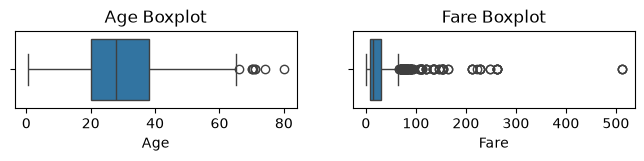

In [16]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

C:\Users\BEBO\AppData\Local\Temp\ipykernel_11788\607448578.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
C:\Users\BEBO\AppData\Local\Temp\ipykernel_11788\607448578.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

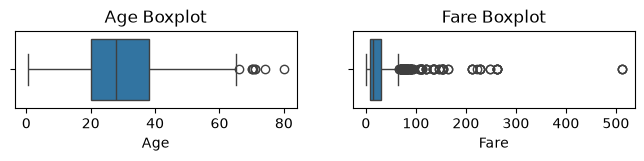

In [18]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [19]:
df.duplicated().sum()

np.int64(111)

In [20]:
df.drop_duplicates(inplace= True)

In [21]:
df.duplicated().sum()

np.int64(0)

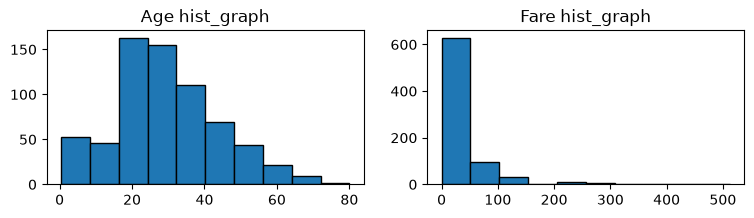

In [22]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


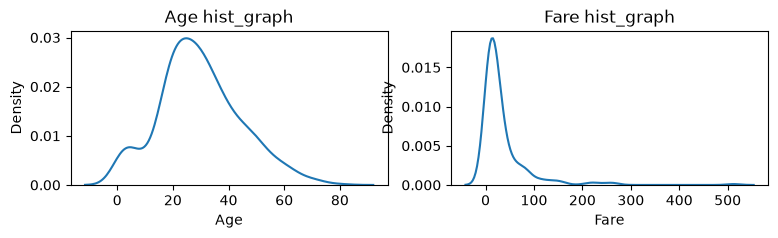

In [23]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [24]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

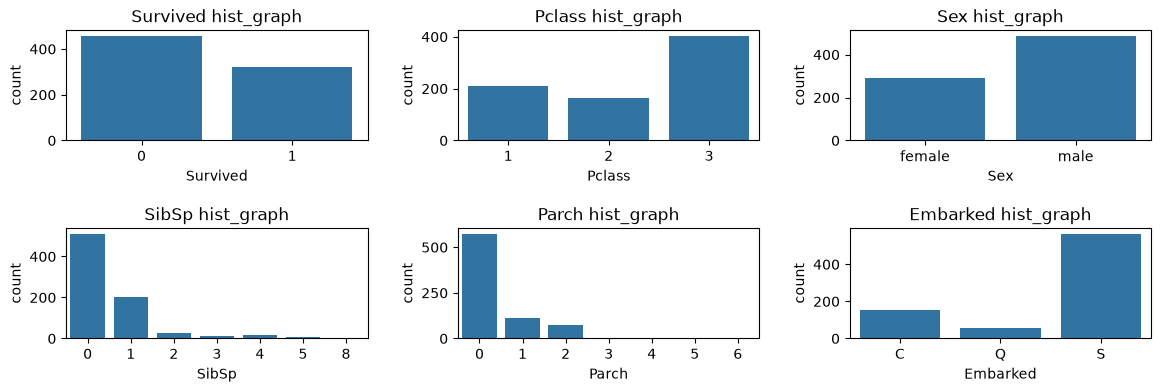

In [42]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.subplots_adjust(wspace=0.3,hspace=0.8)
plt.show()

In [26]:
unique = df['Pclass'].value_counts()
count = unique.values
print(unique)
print(count)

Pclass
3    404
1    210
2    164
Name: count, dtype: int64
[404 210 164]


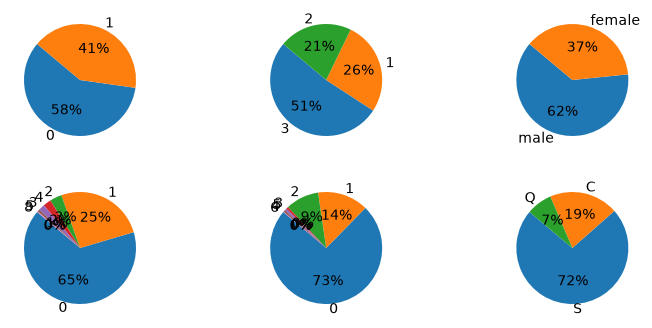

In [27]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

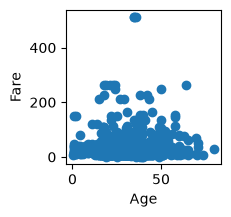

In [28]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

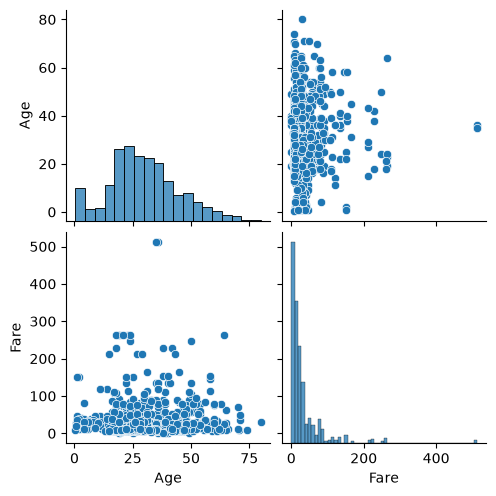

In [29]:
sns.pairplot(df)

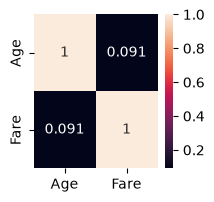

In [30]:
corr  =  df[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()

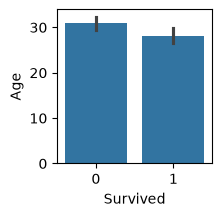

In [31]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived", y="Age",data = df)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

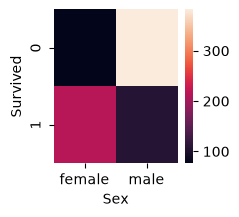

In [32]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="Survived", columns="Sex",values="Age", aggfunc=len)
sns.heatmap(agg)


In [33]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [34]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [35]:
num_cols = df.select_dtypes('number').columns
cat_cols = ["Sex","Embarked"]
print (num_cols)
print (cat_cols)   

Index(['Age', 'Fare'], dtype='str')
['Sex', 'Embarked']


In [36]:
x = df.drop("Survived", axis=1)
y = df[['Survived']]


In [37]:
X_train,X_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state = 42)
print(X_train.isnull().sum())
print(X_train["Sex"].unique())

Pclass       0
Sex          0
Age         80
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64
['male', 'female']
Categories (2, str): ['female', 'male']


In [38]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])
X_test_scaled

array([[0.22090978, 0.01920972],
       [0.53505906, 0.01571255],
       [0.2963056 , 0.12687155],
       [0.30887158, 0.01546857],
       [0.23347575, 0.05074862],
       [0.23347575, 0.02049464],
       [0.39683338, 0.01571255],
       [0.45966323, 0.05074862],
       [0.03242021, 0.06126432],
       [0.58532295, 0.04994347],
       [0.25860769, 0.01917712],
       [       nan, 0.03025399],
       [0.92460417, 0.01517579],
       [0.40939935, 0.01541158],
       [0.58532295, 0.01756683],
       [0.00728826, 0.07746484],
       [       nan, 0.02822072],
       [0.32143755, 0.01690807],
       [       nan, 0.04538098],
       [0.88062327, 0.01512699],
       [0.2083438 , 0.01546857],
       [0.01985423, 0.02042144],
       [       nan, 0.01520019],
       [0.30887158, 0.0585561 ],
       [0.34656949, 0.06929139],
       [0.49736115, 0.01410226],
       [0.37170143, 0.01411046],
       [0.67328474, 0.15276642],
       [0.15807992, 0.03806147],
       [0.17064589, 0.02194234],
       [0.

In [39]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# scaler.fit(x[num_cols])
# x[num_cols] = scaler.transform(x[num_cols])

In [40]:
# from category_encoders import OneHotEncoder

# encoder = OneHotEncoder(cols= string , drop_invariant= True)
# x = encoder.fit_transform(x)